# **Introduction and Problem Statement**
### Loan prediction is used to determine whether a customer is eligible for a loan or not. The goal of this project is to predict loan approval based on customer information such as income, education, loan amount, and credit history.

# **Dataset Understanding**
The dataset contains applicant information such as:

* ApplicantIncome

* CoapplicantIncome

* LoanAmount

* Loan_Amount_Term

* Credit_History

* Gender

* Married

* Education

* Loan_Status (Target Variable)

Loan_Status = Y means loan approved.  

Loan_Status = N means loan rejected.

# **DATA LOADING**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data and display first 5 rows
df=pd.read_csv(r'/content/loan prediction.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# **DATA CLEANING**

In [ ]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check for missing values
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
# Drop rows with any missing values
df = df.dropna()

In [ ]:
# Verify no more missing values
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
# Display data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 1 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            480 non-null    object 
 1   Gender             480 non-null    object 
 2   Married            480 non-null    object 
 3   Dependents         480 non-null    object 
 4   Education          480 non-null    object 
 5   Self_Employed      480 non-null    object 
 6   ApplicantIncome    480 non-null    int64  
 7   CoapplicantIncome  480 non-null    float64
 8   LoanAmount         480 non-null    float64
 9   Loan_Amount_Term   480 non-null    float64
 10  Credit_History     480 non-null    float64
 11  Property_Area      480 non-null    object 
 12  Loan_Status        480 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 52.5+ KB


In [ ]:
# Show descriptive statistics for numerical columns
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,480.000000,480.000000,480.000000,480.000000,480.000000
mean,5364.231250,1581.093583,144.735417,342.050000,0.854167
std,5668.251251,2617.692267,80.508164,65.212401,0.353307
min,150.000000,0.000000,9.000000,36.000000,0.000000
25%,2898.750000,0.000000,100.000000,360.000000,1.000000
50%,3859.000000,1084.500000,128.000000,360.000000,1.000000
75%,5852.500000,2253.250000,170.000000,360.000000,1.000000
max,81000.000000,33837.000000,600.000000,480.000000,1.000000


# **EDA**

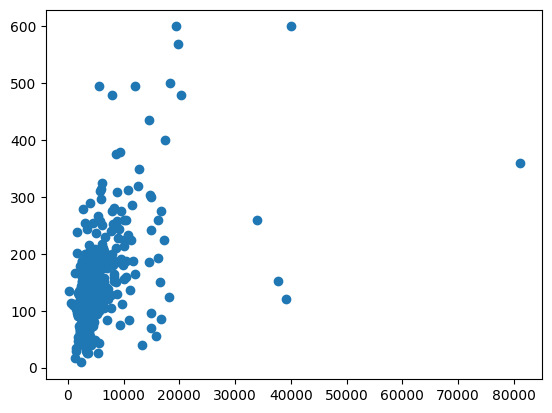

In [ ]:
# Plot ApplicantIncome vs LoanAmount
plt.scatter(df['ApplicantIncome'],df['LoanAmount'])
plt.show()

In [ ]:
# Remove outliers in ApplicantIncome and LoanAmount
df = df[df['ApplicantIncome'] < 30000]
df = df[df['LoanAmount'] < 500]

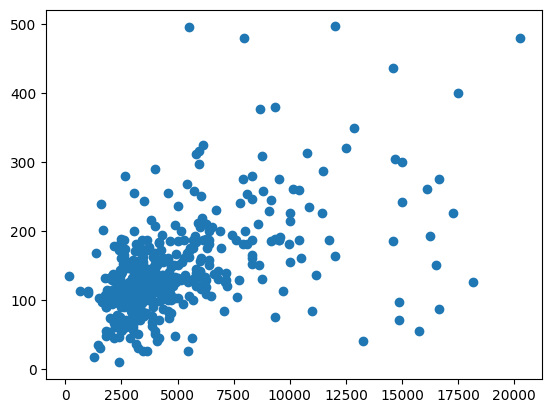

In [ ]:
# Plot ApplicantIncome vs LoanAmount after outlier removal
plt.scatter(df['ApplicantIncome'],df['LoanAmount'])
plt.show()

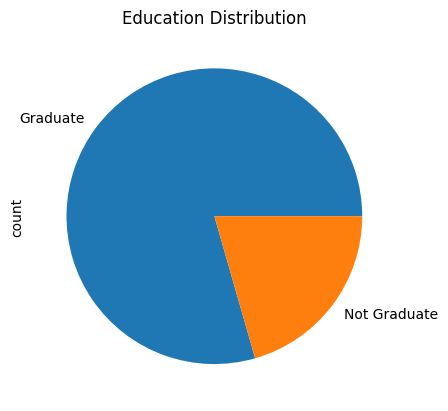

In [ ]:
# Pie chart for Education distribution
df['Education'].value_counts().plot(kind='pie')
plt.title("Education Distribution")
plt.show()

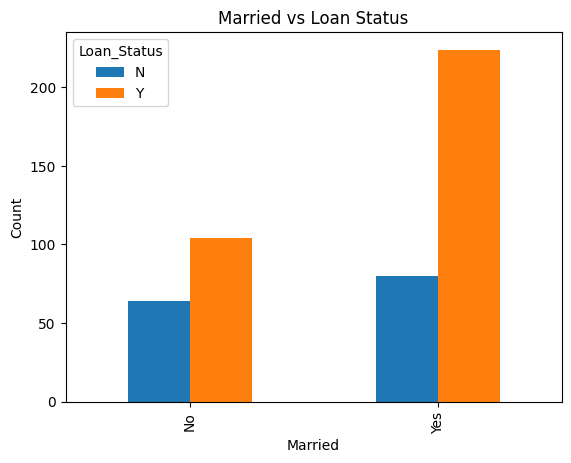

In [ ]:

# Bar chart for Married vs Loan Status
pd.crosstab(df['Married'], df['Loan_Status']).plot(kind='bar')
plt.title("Married vs Loan Status")
plt.xlabel("Married")
plt.ylabel("Count")
plt.show()

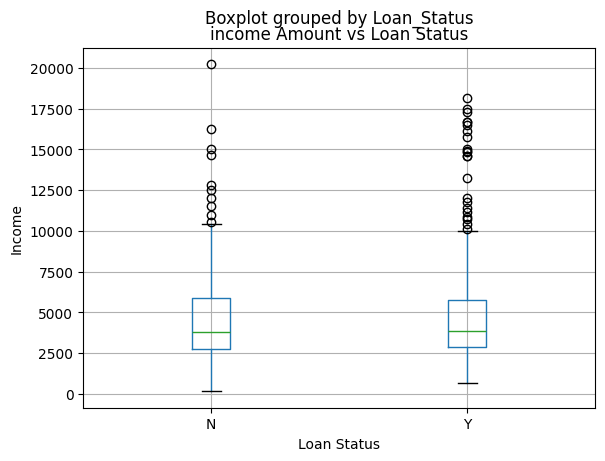

In [ ]:

# Box plot of ApplicantIncome by Loan_Status
df.boxplot(column='ApplicantIncome', by='Loan_Status')
plt.title("income Amount vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Income")
plt.show()

# **MODEL SLECTION AND CLASSIFICATION**

In [ ]:
from sklearn.model_selection import train_test_split # Split data
from sklearn.linear_model import LogisticRegression # Logistic Regression model
from sklearn.metrics import accuracy_score, classification_report # Model evaluation

# Define features (x) and target (y)
x = df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']]
y = df['Loan_Status']

# Split data into training (80%) and testing (20%) sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize and train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

# **MODEL EVALUATION**

In [ ]:
# Make predictions on the test set
y_pred = model.predict(x_test)
# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8315789473684211


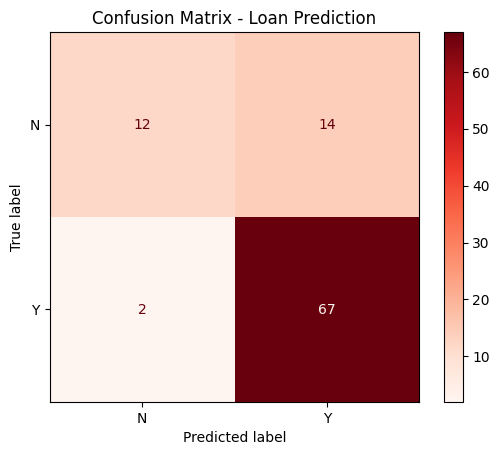

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Confusion Matrix
# Compute and plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['N', 'Y'])
disp.plot(cmap='Reds')
plt.title("Confusion Matrix - Loan Prediction")
plt.show()

# **Conclusion**
The machine learning model successfully predicted loan approval. Important factors affecting loan approval included:

* Married
* Applicant Income
* Loan Amount
* Education

This project helps banks make faster and more accurate loan approval decisions.